In [1]:
import numpy as np
import pandas as pd
import load_data as ld
import seaborn as sns
import graph as gr

In [2]:
households = ld.read_households_distribution_template(file_name="households.xlsx")
households

,region,region_type,1_person,2_persons,3_persons,4_persons,5_persons,6+_persons
0,Центральный федеральный округ,Городские населенные пункты,7532481,3613049,2371442,1439471,569628,352857
1,Центральный федеральный округ,Сельские населенные пункты,1387564,796631,481278,326012,148375,98992
2,Белгородская область,Городские населенные пункты,162958,124748,83360,51741,15970,7509
3,Белгородская область,Сельские населенные пункты,77393,54565,36290,27261,12986,9408
4,Брянская область,Городские населенные пункты,177877,106611,59968,37321,10928,4574
...,...,...,...,...,...,...,...,...
181,Сахалинская область,Сельские населенные пункты,17139,10529,5477,3542,1473,641
182,Еврейская автономная область,Городские населенные пункты,22522,14564,8120,4627,1337,568
183,Еврейская автономная область,Сельские населенные пункты,5843,4894,2879,2090,965,632
184,Чукотский автономный округ,Городские населенные пункты,6615,3965,2598,1569,468,190


In [3]:
def get_household_ratio(households_distribution_template: pd.DataFrame) -> (pd.Series, pd.Series):
    
    tmp = households[["region_type", "1_person", "2_persons", \
                    "3_persons",	"4_persons", "5_persons", "6+_persons"]] \
            .groupby("region_type").sum()
    

    urban = tmp.loc['Городские населенные пункты', :].to_numpy()
    rural = tmp.loc['Сельские населенные пункты', :]

    # перевести данные в доли 
    #urban /= urban.sum()
    #rural /= rural.sum()
    
    return urban, rural
get_household_ratio(households)

(array([41329749, 24091038, 15165080, 9847823, 3528720, 1764608],
       dtype=object),
 1_person      10198668
 2_persons      7628644
 3_persons      4610281
 4_persons      3615973
 5_persons      1906979
 6+_persons     1599318
 Name: Сельские населенные пункты, dtype: object)

In [4]:
age = ld.read_age_sex_distribution_template(file_name="age_sex_distribution_percentage.xlsx")
age

,age,men_women_total,men_total,women_total,men_women_urban,men_urban,women_urban,men_women_rural,men_rural,women_rural,age_group
0,0,0.0098,0.0108,0.009,0.0098,0.011,0.0088,0.0096,0.0102,0.009,0 – 4
1,1,0.0098,0.0108,0.009,0.0098,0.011,0.0088,0.0096,0.0102,0.009,0 – 4
2,2,0.0098,0.0108,0.009,0.0098,0.011,0.0088,0.0096,0.0102,0.009,0 – 4
3,3,0.0098,0.0108,0.009,0.0098,0.011,0.0088,0.0096,0.0102,0.009,0 – 4
4,4,0.0098,0.0108,0.009,0.0098,0.011,0.0088,0.0096,0.0102,0.009,0 – 4
...,...,...,...,...,...,...,...,...,...,...,...
66,66,0.0122,0.0104,0.0138,0.012,0.01,0.0136,0.0132,0.0118,0.0144,65 – 69
67,67,0.0122,0.0104,0.0138,0.012,0.01,0.0136,0.0132,0.0118,0.0144,65 – 69
68,68,0.0122,0.0104,0.0138,0.012,0.01,0.0136,0.0132,0.0118,0.0144,65 – 69
69,69,0.0122,0.0104,0.0138,0.012,0.01,0.0136,0.0132,0.0118,0.0144,65 – 69


In [5]:
sum(age.men_women_urban)

0.9999999999999999

---

In [6]:
import load_data as ld
import numpy as np
import graph as gr

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
plt.style.use('ggplot')

### 0. Задать размер популяции

In [7]:
population_size = 100000

### 1. Построить возрастно-половую пирамиду для фактических данных

In [8]:
# загрузить фактические данные по ворзрастно-половому распределению
age = ld.read_age_sex_distribution_template(file_name="age_sex_distribution_percentage.xlsx")

# сгруппировать данные по возрастным группам
age_grouped = age[["men_women_total", "men_total", "women_total", "men_women_urban",	
                   "men_urban", "women_urban", "men_women_rural", "men_rural",
                   "women_rural", "age_group"]] \
                .groupby("age_group") \
                .sum() \
                .loc[['0 – 4', '5 – 9','10 – 14', '15 – 19', '20 – 24', '25 – 29', '30 – 34',
                      '35 – 39', '40 – 44', '45 – 49', '50 – 54', '55 – 59',
                      '60 – 64', '65 – 69', '70 лет и более'], :] \
                .reset_index()

# расчитать число людей каждой группы исходя из размера популяции
age_grouped[["men_women_total", "men_total", "women_total", "men_women_urban",	
             "men_urban", "women_urban", "men_women_rural", "men_rural",
             "women_rural"]] *= population_size

age_grouped.loc[age_grouped.age_group == "70 лет и более", "age_group"] = "70 лет \n и более"

In [9]:
age_grouped

,age_group,men_women_total,men_total,women_total,men_women_urban,men_urban,women_urban,men_women_rural,men_rural,women_rural
0,0 – 4,4900.0,5400.0,4500.0,4900.0,5500.0,4400.0,4800.0,5100.0,4500.0
1,5 – 9,6400.0,7100.0,5800.0,6400.0,7100.0,5700.0,6500.0,6900.0,6100.0
2,10 – 14,6100.0,6800.0,5600.0,5900.0,6600.0,5300.0,6900.0,7300.0,6500.0
3,15 – 19,5200.0,5800.0,4800.0,5100.0,5700.0,4600.0,5500.0,5900.0,5100.0
4,20 – 24,5000.0,5500.0,4400.0,5000.0,5600.0,4500.0,4900.0,5400.0,4500.0
5,25 – 29,5200.0,5600.0,4800.0,5200.0,5600.0,4800.0,5100.0,5600.0,4700.0
6,30 – 34,7600.0,8000.0,7100.0,7800.0,8300.0,7400.0,6700.0,7300.0,6100.0
7,35 – 39,8800.0,9300.0,8300.0,9100.0,9600.0,8700.0,7800.0,8300.0,7200.0
8,40 – 44,7800.0,8200.0,7500.0,8100.0,8400.0,7800.0,7100.0,7400.0,6700.0
9,45 – 49,7000.0,7200.0,6900.0,7100.0,7300.0,7000.0,6700.0,6900.0,6600.0


### 2. Нарисовать возрастно-половые пирамиды для фактических расперделений

In [10]:
def plot_age_sex_distribution(max_xlimit: int,
                              population: pd.DataFrame):

    plt.figure(figsize=(20, 10))
    fig, axs = plt.subplots(1, 2, figsize=(22, 8))

    axs[0].set_xlim(-max_xlimit, max_xlimit)
    axs[1].set_xlim(-max_xlimit, max_xlimit)

    AgeClass= population["age_group"]

    sns.barplot(x=-1*population.men_urban, y="age_group", data=population,
                order=AgeClass, color="red", label="мужчины", ax=axs[0])

    sns.barplot(x=population.women_urban, y="age_group", data=population,
                order=AgeClass, color="blue", label="женщины", ax=axs[0])

    sns.barplot(x=-1*population.men_rural, y="age_group", data=population,
                order=AgeClass, color="red", label="мужчины", ax=axs[1])

    sns.barplot(x=population.women_rural, y="age_group", data=population,
                order=AgeClass, color="blue", label="женщины", ax=axs[1])


    axs[0].set_title("Городское население")
    axs[0].set_xlabel("Численность")
    axs[0].set_ylabel("Возрастная группа")

    axs[1].set_title("Сельское население")
    axs[1].set_xlabel("Численность")
    axs[1].set_ylabel("Возрастная группа")

    axs[0].axvline(0, 1,0, color="black")
    axs[0].legend(prop={'size': 15})

    axs[1].axvline(0, 1,0, color="black")
    axs[1].legend(prop={'size': 15})


    def abs_fmt(x, pos):
        """Функция форматирования для модуля"""
        return f'{int(abs(x))}'

    from matplotlib.ticker import FuncFormatter
    for ax in axs.flatten():
        ax.xaxis.set_major_formatter(FuncFormatter(abs_fmt))


<Figure size 2000x1000 with 0 Axes>

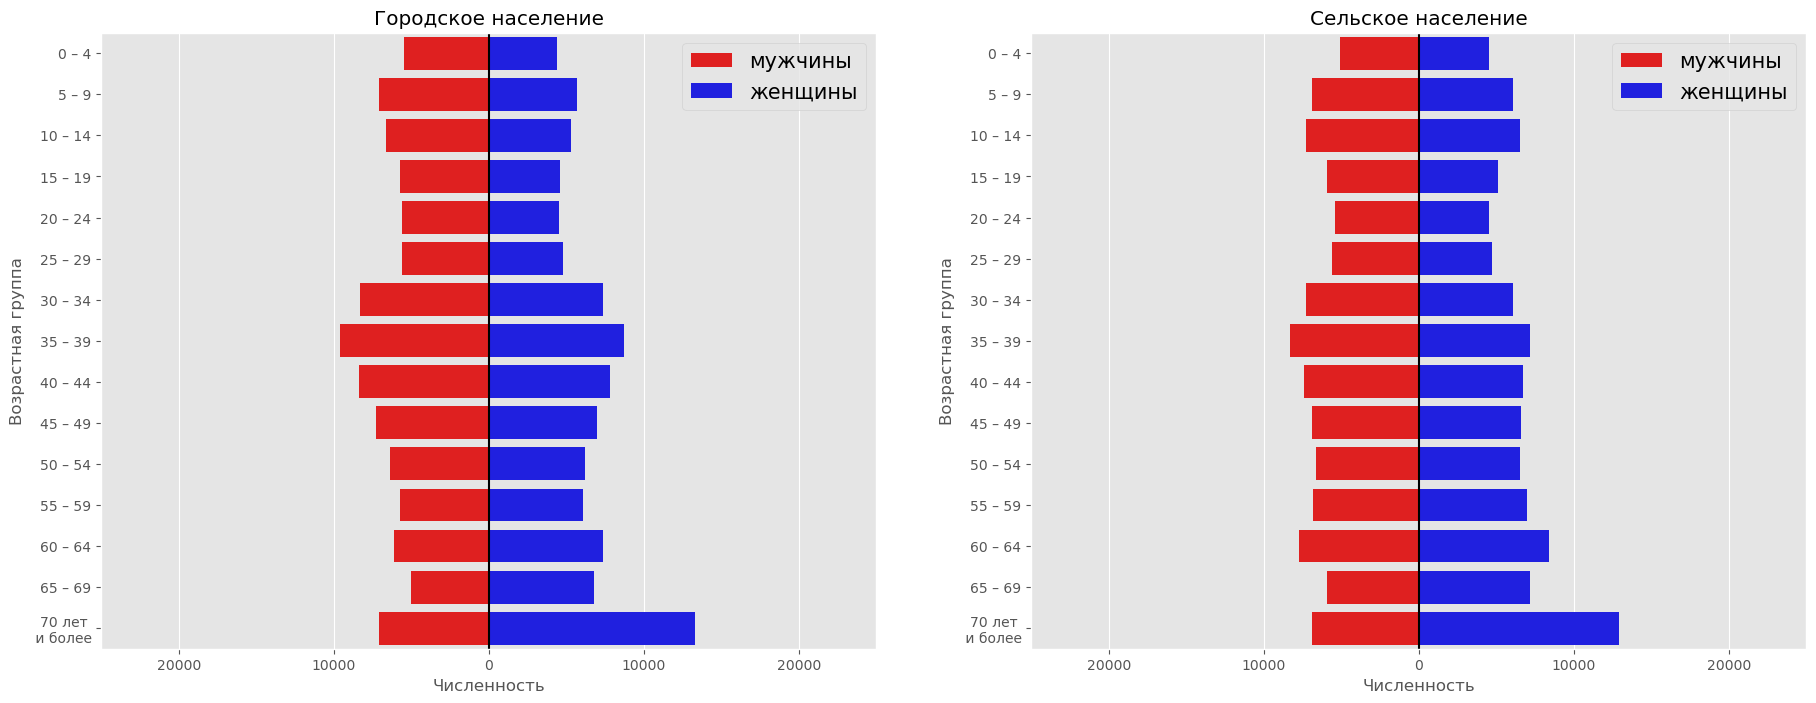

In [11]:
plot_age_sex_distribution(max_xlimit = population_size/4,
                          population = age_grouped);

### 3. Создать популяуию на освнове фактического возрастно-полового распределения 

In [12]:
households = ld.read_households_distribution_template(file_name="households.xlsx")
age = ld.read_age_sex_distribution_template(file_name="age_sex_distribution_percentage.xlsx")
manufactures = ld.read_manufactures_distribution_template(file_name="manufactures.xlsx")
schools = ld.read_schools_distribution_template(file_name="schools.xlsx")

In [13]:
_, urban_population_raw_50000 = gr.create_population(households_distribution_template=households,
                                                  age_sex_distribution_template=age,
                                                  population_type="urban",
                                                  population_size=10000,
                                                  schools_distribution_template=schools)

urban_population_raw_50000.to_pickle('urban_population_raw_50000.pkl')

urban_population = urban_population_raw_50000.groupby(["age_group", "sex", "population_type"], as_index=False).count()

AttributeError: module 'graph' has no attribute 'create_population'

In [20]:
urban_population

,age_group,sex,population_type,id,system_record_number,age,id_in_sex_group,household_id,role,school_number,manufacture_number,department_number,university_number
0,0 – 4,man,urban,210,210,210,210,210,210,210,210,210,210
1,0 – 4,woman,urban,151,151,151,151,151,151,151,151,151,151
2,10 – 14,man,urban,224,224,224,224,224,224,224,224,224,224
3,10 – 14,woman,urban,169,169,169,169,169,169,169,169,169,169
4,15 – 19,man,urban,275,275,275,275,275,275,275,275,275,275
5,15 – 19,woman,urban,200,200,200,200,200,200,200,200,200,200
6,20 – 24,man,urban,275,275,275,275,275,275,275,275,275,275
7,20 – 24,woman,urban,240,240,240,240,240,240,240,240,240,240
8,25 – 29,man,urban,415,415,415,415,415,415,415,415,415,415
9,25 – 29,woman,urban,370,370,370,370,370,370,370,370,370,370


In [15]:
rural_connections_matrix, rural_population_raw_50000 = gr.create_population(households_distribution_template=households,
                                                                            age_sex_distribution_template=age,
                                                                            population_type="rural",
                                                                            population_size=3000,
                                                                            schools_distribution_template=schools)

rural_population_raw_50000.to_pickle('rural_population_raw_50000.pkl')

rural_population = rural_population_raw_50000.groupby(["age_group", "sex", "population_type"], as_index=False).count()

2024-02-18 14:04:11.811624 : Запуск функции создания популяции ... 
2024-02-18 14:04:11.827248 : Создается популяция мужчин на основе шаблона ... 
2024-02-18 14:04:11.827248 : Создается популяция женщин на основе шаблона ... 
2024-02-18 14:04:11.849387 : Формирование домохозяйств ... 
2024-02-18 14:04:11.896265 : Создание матрицы контактов внутри домохозяйств ... 
2024-02-18 14:04:12.096798 : Создается контакты внутри школ ... 
2024-02-18 14:04:12.281702 : Создается контакты внутри предприятий ... 
2024-02-18 14:04:13.215341 : Создается контакты внутри университетов ... 
2024-02-18 14:04:13.215341 : Создается слуяайные контакты внутри популяции ... 
2024-02-18 14:04:13.230966 : Расчет окончен ... 


In [16]:
type(rural_connections_matrix)


scipy.sparse._lil.lil_matrix

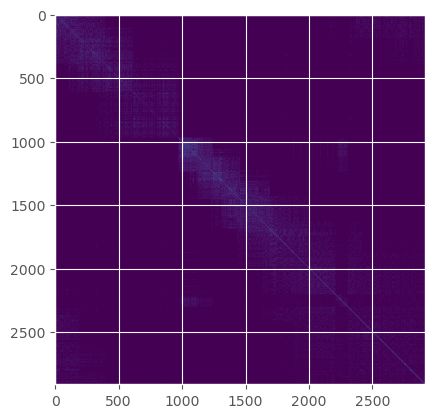

0

In [17]:
gr.plot_heat_map(rural_connections_matrix)

In [18]:
population_predicted = urban_population.query("sex == 'man'")[["age_group", "id"]] \
                                       .rename(columns={"id": "men_urban"}) \
                                       .merge(urban_population.query("sex == 'woman'")[["age_group", "id"]] \
                                                              .rename(columns={"id": "women_urban"}),
                                              on="age_group", how="left") \
                                       .merge(rural_population.query("sex == 'woman'")[["age_group", "id"]] \
                                                              .rename(columns={"id": "women_rural"}),
                                              on="age_group", how="left") \
                                       .merge(rural_population.query("sex == 'man'")[["age_group", "id"]] \
                                                              .rename(columns={"id": "men_rural"}),
                                              on="age_group", how="left")

In [19]:
population_predicted.to_pickle('population_predicted.pkl')
#df_read = pd.read_pickle('dataframe.pkl')

In [20]:
population_predicted=  population_predicted.set_index("age_group")

In [21]:
population_predicted

,men_urban,women_urban,women_rural,men_rural
age_group,,,,
0 – 4,61,50,63,74
10 – 14,74,52,72,81
15 – 19,80,54,64,80
20 – 24,80,70,70,80
25 – 29,120,110,90,105
30 – 34,140,130,105,120
35 – 39,125,115,100,110
40 – 44,105,105,95,100
45 – 49,105,85,90,100


In [59]:
np.random.randint(0, 2)

1

In [27]:
from scipy import stats   # модуль для работы со статистикой

Text(0.5, 0, '$x$')

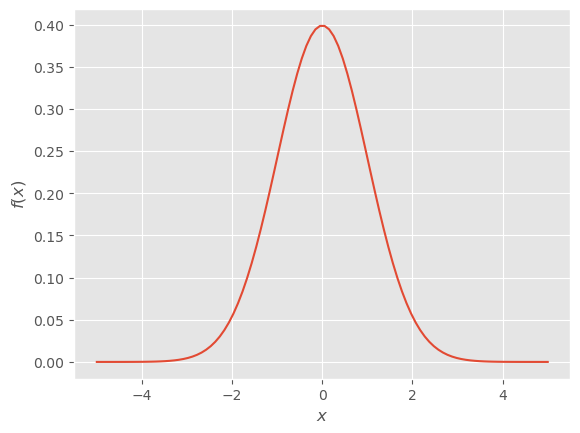

In [34]:
norm_rv = stats.norm(loc=0, scale=1)  # задали нерератор loc - матожидание, scale - срквоткл

x = np.linspace(-5, 5, 100)
pdf = norm_rv.pdf(x)
plt.plot(x, pdf)
plt.ylabel("$f(x)$")
plt.xlabel("$x$")



In [23]:
population_predicted = population_predicted.loc[['0 – 4', '5 – 9','10 – 14', '15 – 19', '20 – 24', '25 – 29', '30 – 34',
                      '35 – 39', '40 – 44', '45 – 49', '50 – 54', '55 – 59',
                      '60 – 64', '65 – 69', '70 лет и более'], :].reset_index()

In [24]:
population_predicted

,age_group,men_urban,women_urban,women_rural,men_rural
0,0 – 4,61,50,63,74
1,5 – 9,68,57,90,103
2,10 – 14,74,52,72,81
3,15 – 19,80,54,64,80
4,20 – 24,80,70,70,80
5,25 – 29,120,110,90,105
6,30 – 34,140,130,105,120
7,35 – 39,125,115,100,110
8,40 – 44,105,105,95,100
9,45 – 49,105,85,90,100


### 3.1 Нарисовать возрастно-половое распределение сгенерированной популяции

<Figure size 2000x1000 with 0 Axes>

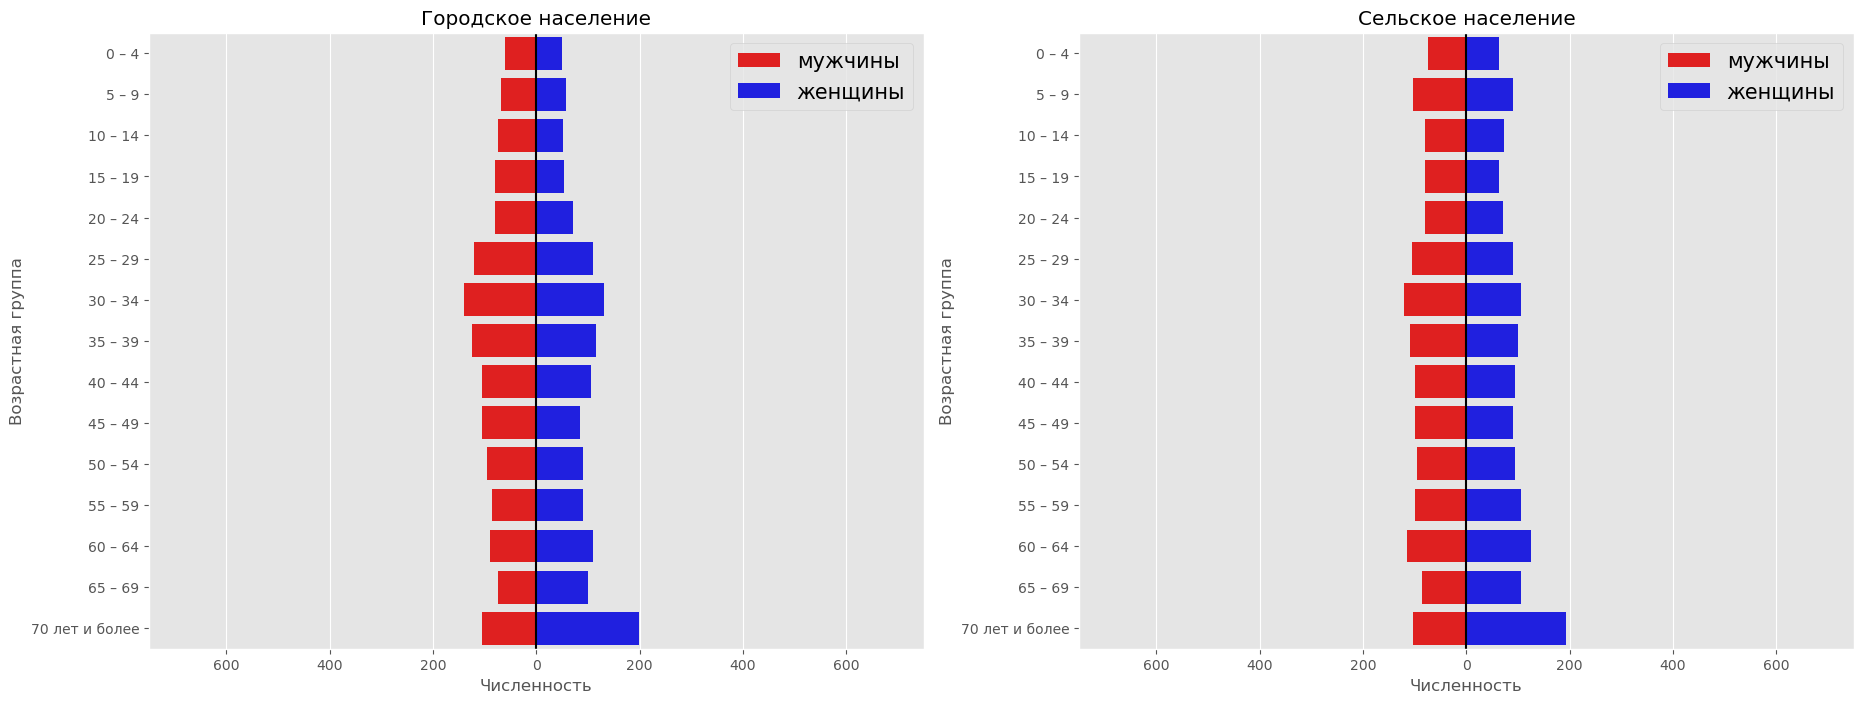

In [26]:
plot_age_sex_distribution(max_xlimit= 3000/4,
                          population=population_predicted)

---

### 4 Посмотреть распределения внутри домохозяйств для фактических данных

In [20]:
households = ld.read_households_distribution_template(file_name="households.xlsx")
households

,region,region_type,1_person,2_persons,3_persons,4_persons,5_persons,6+_persons
0,Центральный федеральный округ,Городские населенные пункты,7532481,3613049,2371442,1439471,569628,352857
1,Центральный федеральный округ,Сельские населенные пункты,1387564,796631,481278,326012,148375,98992
2,Белгородская область,Городские населенные пункты,162958,124748,83360,51741,15970,7509
3,Белгородская область,Сельские населенные пункты,77393,54565,36290,27261,12986,9408
4,Брянская область,Городские населенные пункты,177877,106611,59968,37321,10928,4574
...,...,...,...,...,...,...,...,...
181,Сахалинская область,Сельские населенные пункты,17139,10529,5477,3542,1473,641
182,Еврейская автономная область,Городские населенные пункты,22522,14564,8120,4627,1337,568
183,Еврейская автономная область,Сельские населенные пункты,5843,4894,2879,2090,965,632
184,Чукотский автономный округ,Городские населенные пункты,6615,3965,2598,1569,468,190


In [21]:
households_urban = households.query("region_type == 'Городские населенные пункты'")
households_urban

,region,region_type,1_person,2_persons,3_persons,4_persons,5_persons,6+_persons
0,Центральный федеральный округ,Городские населенные пункты,7532481,3613049,2371442,1439471,569628,352857
2,Белгородская область,Городские населенные пункты,162958,124748,83360,51741,15970,7509
4,Брянская область,Городские населенные пункты,177877,106611,59968,37321,10928,4574
6,Владимирская область,Городские населенные пункты,224018,141066,80540,47575,13318,4881
8,Воронежская область,Городские населенные пункты,346781,212358,123482,71537,20314,5437
...,...,...,...,...,...,...,...,...
176,Амурская область,Городские населенные пункты,111855,66186,40672,24414,7009,2513
178,Магаданская область,Городские населенные пункты,32342,17517,10219,5311,1373,481
180,Сахалинская область,Городские населенные пункты,84466,48189,28285,17176,5741,2503
182,Еврейская автономная область,Городские населенные пункты,22522,14564,8120,4627,1337,568


Число семей, состоящие из 1, 2 и тд человек 

In [22]:
households_grouped = households[["region_type", "1_person", "2_persons",
                                 "3_persons", "4_persons", "5_persons", "6+_persons"]] \
                        .groupby("region_type").sum().reset_index()
households_grouped

,region_type,1_person,2_persons,3_persons,4_persons,5_persons,6+_persons
0,Городские населенные пункты,41329749,24091038,15165080,9847823,3528720,1764608
1,Сельские населенные пункты,10198668,7628644,4610281,3615973,1906979,1599318


<Figure size 2000x1000 with 0 Axes>

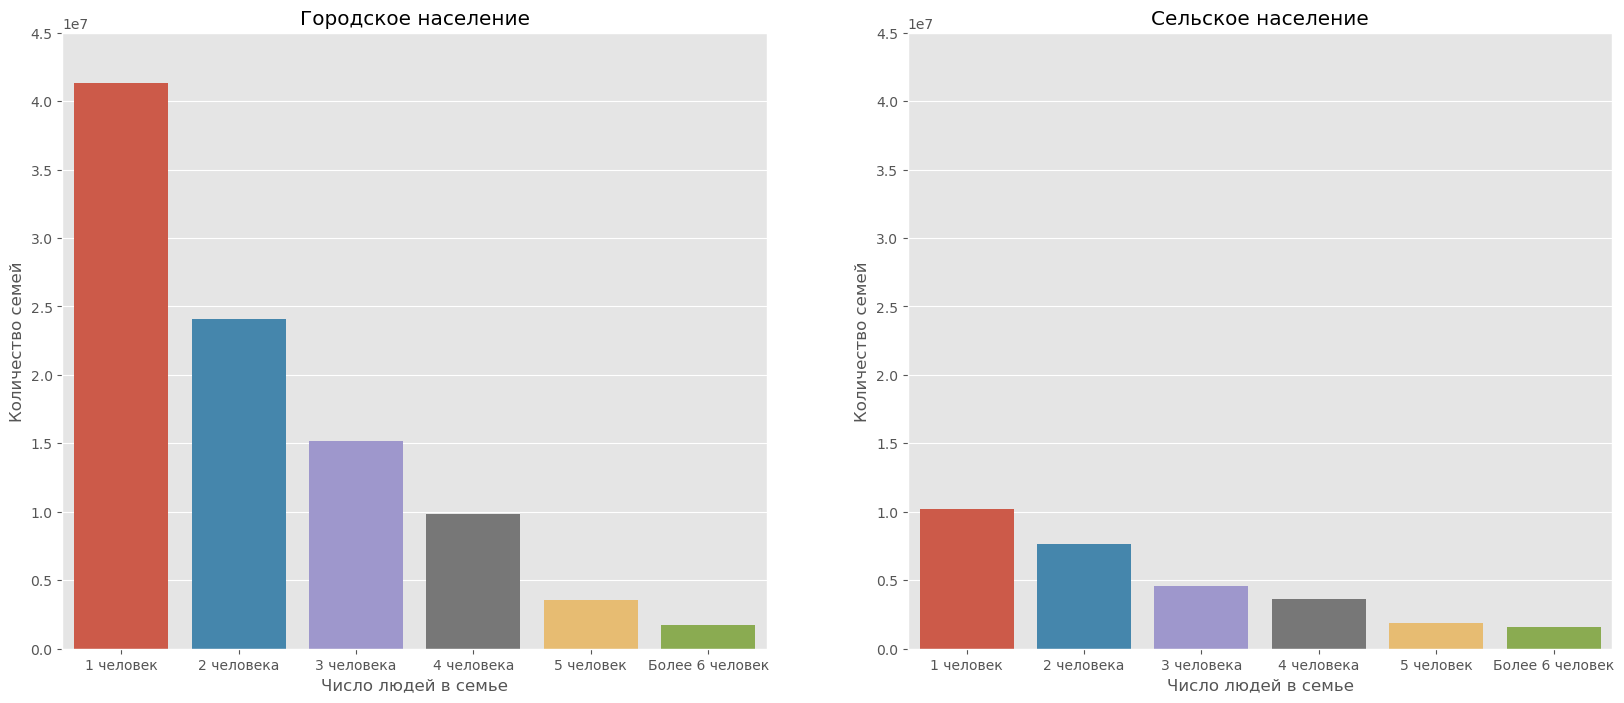

In [24]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(1, 2, figsize=(20, 8))
plt.style.use('ggplot')


axs[0].set_ylim(0, 4.5*10**7)
axs[1].set_ylim(0, 4.5*10**7)

df_melted_urban = households_grouped \
                    .query("region_type == 'Городские населенные пункты'")[["1_person","2_persons","3_persons",
                                                                            "4_persons","5_persons","6+_persons"]] \
                    .rename(columns={"1_person": "1 человек",
                                     "2_persons": "2 человека",
                                     "3_persons": "3 человека",
                                     "4_persons": "4 человека",
                                     "5_persons": "5 человек",
                                     "6+_persons": "Более 6 человек"}) \
                    .melt()

df_melted_rural = households_grouped \
                    .query("region_type == 'Сельские населенные пункты'")[["1_person","2_persons","3_persons",
                                                                           "4_persons","5_persons","6+_persons"]] \
                    .rename(columns={"1_person": "1 человек",
                                     "2_persons": "2 человека",
                                     "3_persons": "3 человека",
                                     "4_persons": "4 человека",
                                     "5_persons": "5 человек",
                                     "6+_persons": "Более 6 человек"}) \
                    .melt()

sns.barplot(x='variable', y='value', data=df_melted_rural, ax=axs[1])
sns.barplot(x='variable', y='value', data=df_melted_urban, ax=axs[0])

axs[0].set_title("Городское население")
axs[0].set_xlabel("Число людей в семье")
axs[0].set_ylabel("Количество семей")

axs[1].set_title("Сельское население")
axs[1].set_xlabel("Число людей в семье")
axs[1].set_ylabel("Количество семей");

### 4 Посмотреть распределения внутри домохозяйств для сгенерированых данных

In [25]:
rural_population

,age_group,sex,population_type,id,system_record_number,age,id_in_sex_group,household_id,role,school_number,manufacture_number,university_number
0,0 – 4,man,rural,1270,1270,1270,1270,1270,1270,1270,1270,1270
1,0 – 4,woman,rural,1120,1120,1120,1120,1120,1120,1120,1120,1120
2,10 – 14,man,rural,1475,1475,1475,1475,1475,1475,1475,1475,1475
3,10 – 14,woman,rural,1270,1270,1270,1270,1270,1270,1270,1270,1270
4,15 – 19,man,rural,668,668,668,668,668,668,668,668,668
5,15 – 19,woman,rural,678,678,678,678,678,678,678,678,678
6,20 – 24,man,rural,1395,1395,1395,1395,1395,1395,1395,1395,1395
7,20 – 24,woman,rural,936,936,936,936,936,936,936,936,936
8,25 – 29,man,rural,1820,1820,1820,1820,1820,1820,1820,1820,1820
9,25 – 29,woman,rural,1525,1525,1525,1525,1525,1525,1525,1525,1525


In [27]:
tmp = urban_population_raw_50000.groupby("household_id").count().groupby("id").count().reset_index()[["id", "age"]].head(6).transpose()
tmp.columns = tmp.loc["id", :]
tmp = tmp.tail(1)
tmp_urban = tmp.melt()
tmp_urban

,id,value
0,1,17932
1,2,6288
2,3,2639
3,4,1282
4,5,367
5,6,151


In [30]:
tmp= rural_population_raw_50000.groupby("household_id").count().groupby("id").count().reset_index()[["id", "age"]].head(6).transpose()
tmp.columns = tmp.loc["id", :]
tmp = tmp.tail(1)
tmp_rural = tmp.melt()
tmp_rural

,id,value
0,1,15875
1,2,6448
2,3,2597
3,4,1526
4,5,643
5,6,449


<Figure size 2000x1000 with 0 Axes>

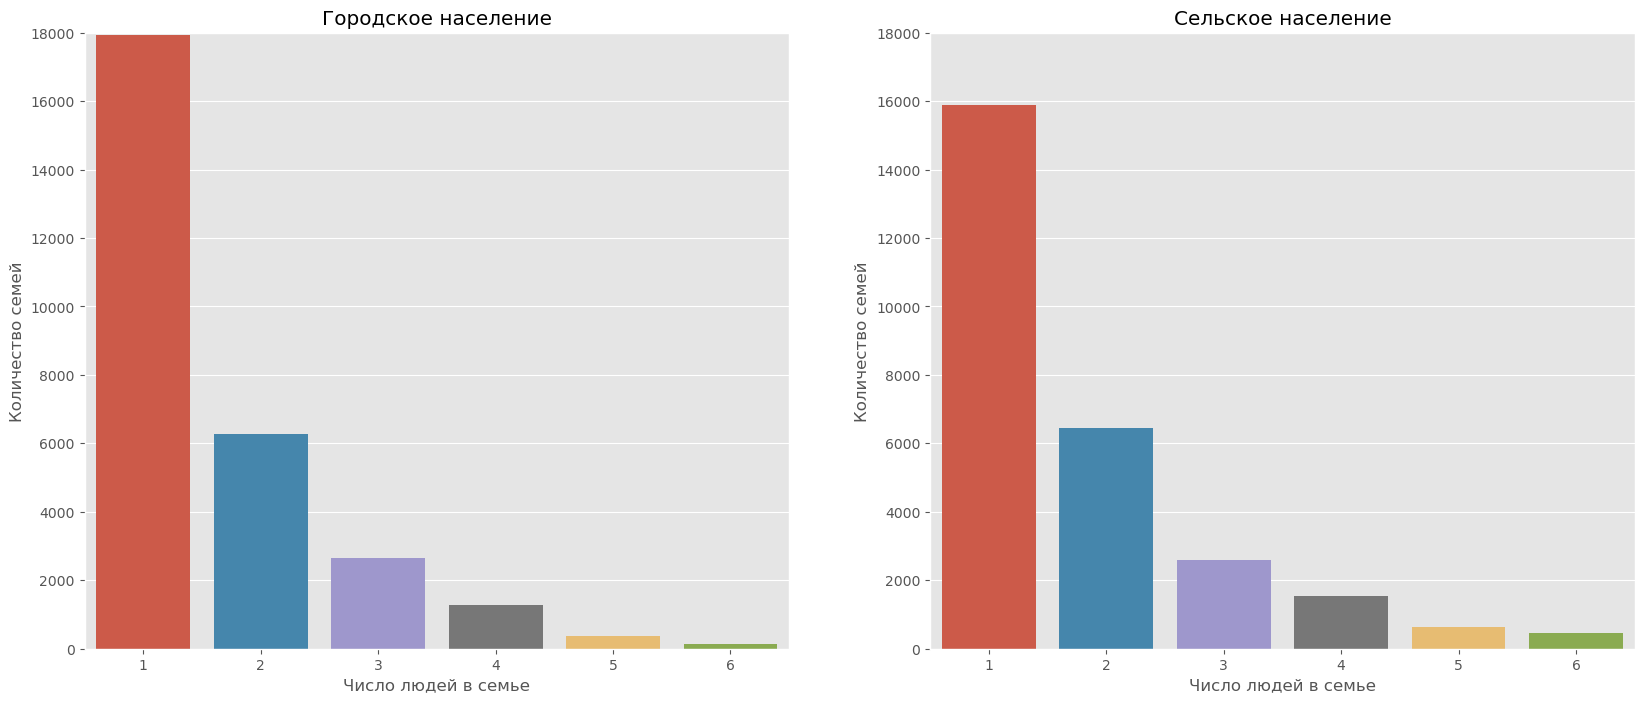

In [31]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(1, 2, figsize=(20, 8))
plt.style.use('ggplot')


axs[0].set_ylim(0, 18000)
axs[1].set_ylim(0, 18000)



sns.barplot(x='id', y='value', data=tmp_rural, ax=axs[1])
sns.barplot(x='id', y='value', data=tmp_urban, ax=axs[0])

axs[0].set_title("Городское население")
axs[0].set_xlabel("Число людей в семье")
axs[0].set_ylabel("Количество семей")

axs[1].set_title("Сельское население")
axs[1].set_xlabel("Число людей в семье")
axs[1].set_ylabel("Количество семей");

---

* надо поменять связи внутри предприятий
* надо написать код, который будет генерировать по мат модели популяцию
* надо разобраться с багом, почему нет одной группы

In [161]:
rural_population_raw_50000.groupby("household_id").count().groupby("id").count().reset_index()[["id", "age"]].head(6)

,id,age
0,1,15875
1,2,6448
2,3,2597
3,4,1526
4,5,643
5,6,449


In [179]:
tmp= rural_population_raw_50000.groupby("household_id").count().groupby("id").count().reset_index()[["id", "age"]].head(6).transpose()
tmp.columns = tmp.loc["id", :]
tmp = tmp.tail(1)
tmp_rural = tmp.melt()
tmp_rural

,id,value
0,1,15875
1,2,6448
2,3,2597
3,4,1526
4,5,643
5,6,449


### SIR model

A simple mathematical description of the spread of a disease in a 
population is the so-called SIR model, which divides the (fixed) 
population of $N$ individuals into three "compartments" which may vary as a function of time, $t$:

* S(t) are those susceptible but not yet infected with the disease
* I(t) is the number of infectious individuals
* R(t) are those individuals who have recovered from the disease and now have immunity to it

The SIR model describes the change in the population of each of these compartments in terms of two parameters, $\beta$
 and $\gamma$. $\beta$ describes the effective contact rate of the disease: an infected individual comes into contact with $\beta N$ other individuals per unit time (of which the fraction that are susceptible to contracting the disease is $S/N$). $\gamma$ is the mean recovery rate: that is, $1/\gamma$ is the mean period of time during which an infected individual can pass it on.

The differential equations describing this model were first derived by Kermack and McKendrick [Proc. R. Soc. A, 115, 772 (1927)]:


\begin{aligned}
\frac{dS}{dt} & = -\beta SI N, \\
\frac{dI}{dt} & = \beta SI N - \gamma I, \\
\frac{dR}{dt} & = \gamma I.
\end{aligned}

The following Python code integrates these equations for a disease characterised by parameters $\beta=0.2$
, $1/\gamma=10$ days in a population of $N=1000$ (perhaps 'flu in a school). The model is started with a single infected individual on day 0: $I(0)=1$. The plotted curves of $S(t)$, $I(t)$ and $R(t)$ are styled to look a bit nicer than Matplotlib's defaults.

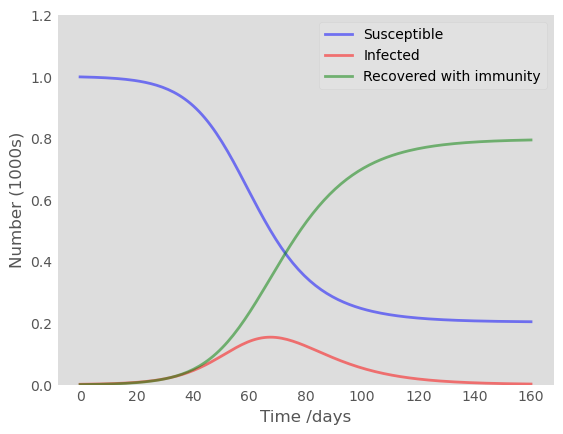

In [61]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Total population, N.
N = 1000
# Initial number of infected and recovered individuals, I0 and R0.
I0, R0 = 1, 0
# Everyone else, S0, is susceptible to infection initially.
S0 = N - I0 - R0
# Contact rate, beta, and mean recovery rate, gamma, (in 1/days).
beta, gamma = 0.2, 1./10 
# A grid of time points (in days)
t = np.linspace(0, 160, 160)

# The SIR model differential equations.
def deriv(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

# Initial conditions vector
y0 = S0, I0, R0
# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma))
S, I, R = ret.T

# Plot the data on three separate curves for S(t), I(t) and R(t)
fig = plt.figure(facecolor='w')
ax = fig.add_subplot(111, facecolor='#dddddd', axisbelow=True)
ax.plot(t, S/1000, 'b', alpha=0.5, lw=2, label='Susceptible')
ax.plot(t, I/1000, 'r', alpha=0.5, lw=2, label='Infected')
ax.plot(t, R/1000, 'g', alpha=0.5, lw=2, label='Recovered with immunity')
ax.set_xlabel('Time /days')
ax.set_ylabel('Number (1000s)')
ax.set_ylim(0,1.2)
ax.yaxis.set_tick_params(length=0)
ax.xaxis.set_tick_params(length=0)
ax.grid()
legend = ax.legend()
legend.get_frame().set_alpha(0.5)
for spine in ('top', 'right', 'bottom', 'left'):
    ax.spines[spine].set_visible(False)
plt.show()


предприятия разного размера сдлеать (линейная зависимость от числа сотрудников) данные мне должны присласть по америке 
small world - это как распределять контакты для маленьких компаний. Так же в классе. Можно не смотреть на департаменты, надо получить гитограмму.
надо подобрать папаметр - сколько ребер надо перекинуть




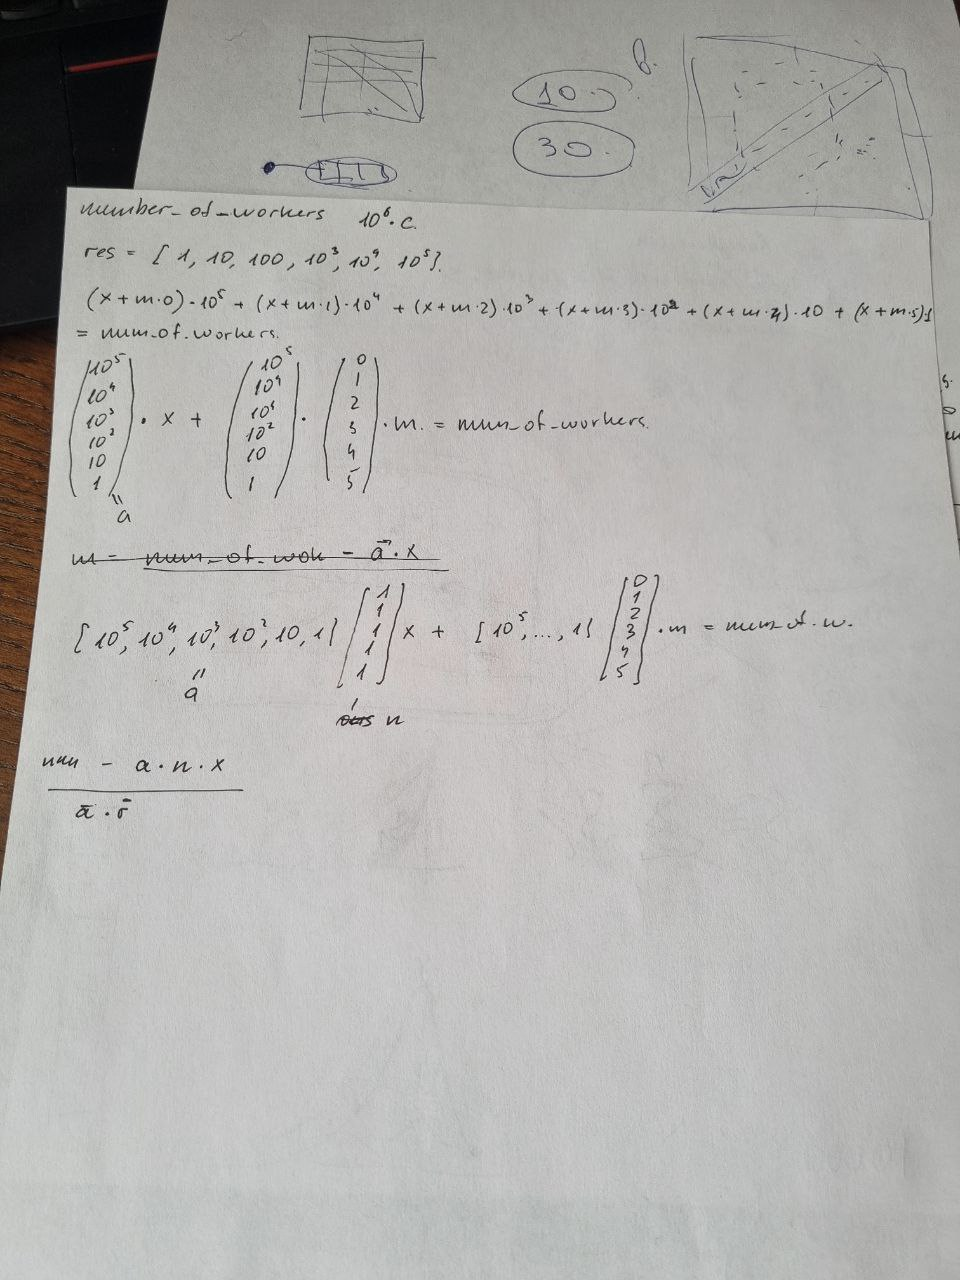


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [8]:
# число людей трудоспособного возраста
number_of_wokers = 2345565

# число предприятий максимального размера
lagest_manufactures_number = 19

# определить порядок числа number_of_wokers
order = int(np.floor(np.log10(number_of_wokers)))

a = np.power(10, np.arange(order))[::-1]

m = int((number_of_wokers - a @ np.ones(a.size) * lagest_manufactures_number) // (a @ np.arange(a.size)))
manufactures_sizes_series = pd.Series(np.repeat(a, m*np.arange(a.size) + lagest_manufactures_number)).value_counts() 
manufactures_sizes_dict = manufactures_sizes_series.to_dict()

In [9]:
manufactures_sizes_dict

{1: 109, 10: 91, 100: 73, 1000: 55, 10000: 37, 100000: 19}

In [35]:
def polot_manufactures_size_distribution(d:dict):
    fig, ax = plt.subplots()
    keys, values = list(dist.keys()), list(dist.values())
    # поставить логарифмическую шкалу 
    ax.set_xscale('log')
    # построить график
    ax.plot(keys, values)
    ax.scatter(keys, values)
    ax.grid(True)
    ax.set_xlabel("Размер предприятия (число сотрудников)")
    ax.set_ylabel("Количество предприятий")
    ax.set_title("Распределение предприятий по размеру")

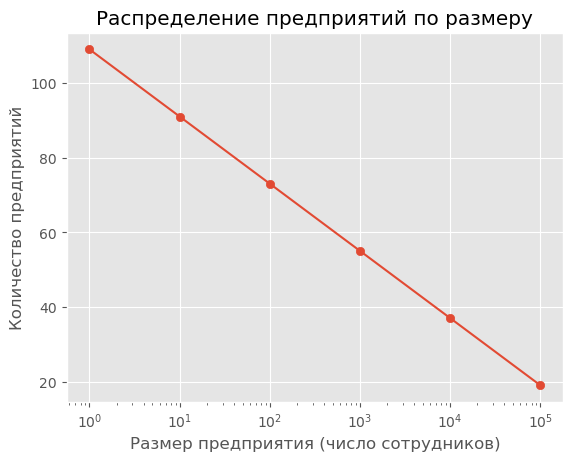

In [36]:

polot_manufactures_size_distribution(manufactures_sizes_dict)

<Axes: >

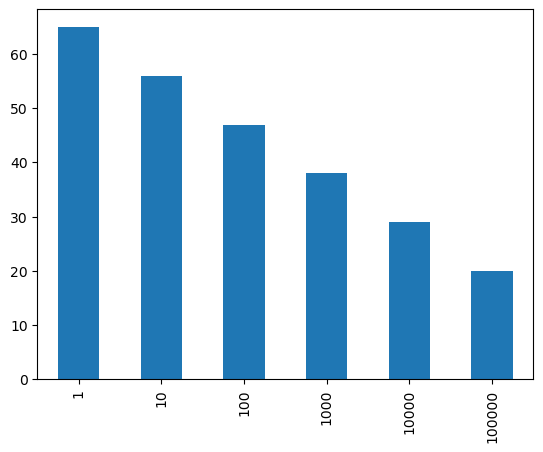

In [186]:
pd.Series(np.repeat(a, m*np.arange(a.size) + x)).value_counts().sort_index().plot(kind='bar')

In [38]:
from scipy.sparse import lil_matrix

### Нарисовать распределения внутри домохозяйств

In [ ]:
ff = gr.MyPopulation()
ff.create_population("urban",100000)

2024-03-06 16:50:11.575601 : Запуск функции создания популяции ... 
2024-03-06 16:50:13.623448 : Создается популяция мужчин на основе шаблона ... 
2024-03-06 16:50:13.708957 : Создается популяция женщин на основе шаблона ... 
2024-03-06 16:50:13.837043 : Формирование домохозяйств ... 
2024-03-06 16:50:14.144004 : Создание матрицы контактов внутри домохозяйств ... 


2024-03-05 17:13:38.083310 : Вычисление степеней вершин для матрицы контактов ... 


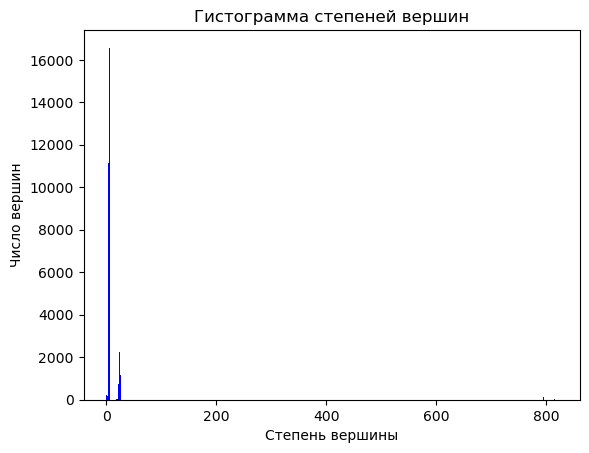

0

In [3]:
ff.plot_total_connections_hist()

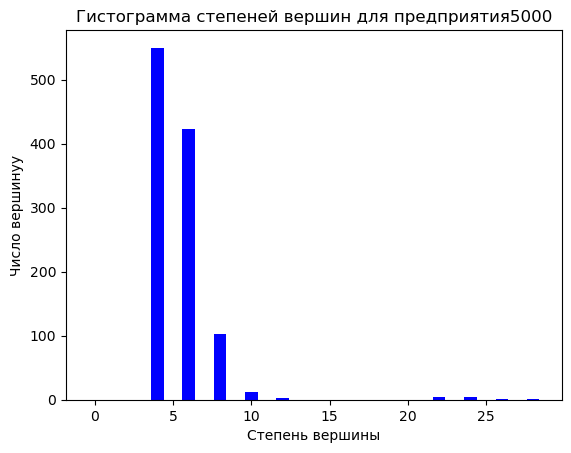

0

In [5]:
ff.plot_manufactures_connections_hist()

2024-03-04 15:29:31.544423 : Рисуется распределение домохозяйств по размеру ... 


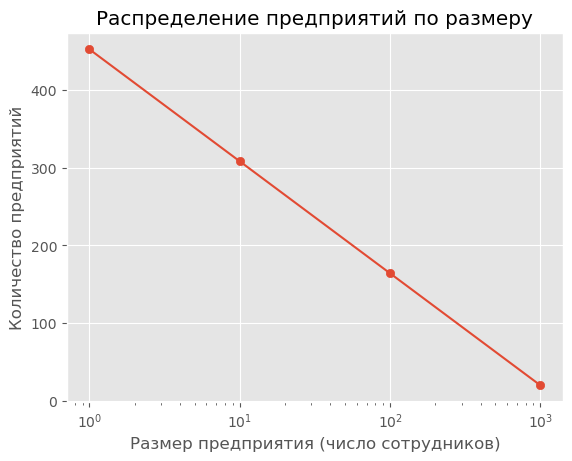

0

In [21]:
ff.plot_manufactures_size_distribution()

In [60]:
ff.plot_graph()

2024-03-04 15:43:07.320463 : Создается граф по матрице контактов ... 
2024-03-04 15:43:21.167059 : Выполняется отрисовка построенного графа ... 


KeyError: 1

KeyboardInterrupt: 

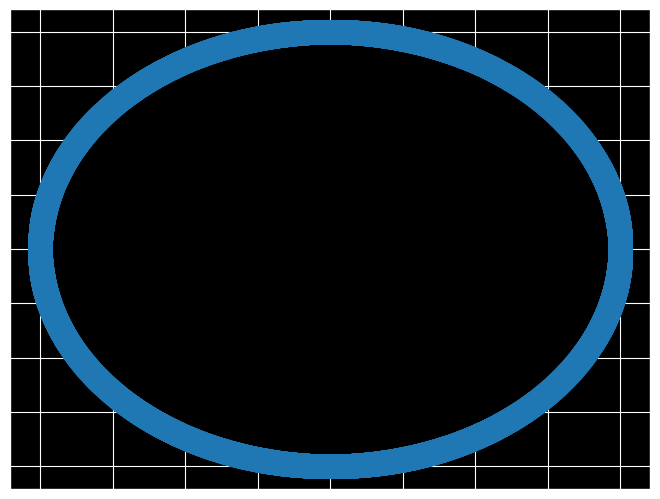

In [61]:
ff.plot_manufactures_connections_graph()

- нарисовать картинку по возрастам и распределение по вершинам
- написовать общую для всей популяции
- решить систему для каждого i, где i  это степень вершины
- можно составить системы и решить для каждого к
- для разных к нарисовать графики для I S R
- посмотреть что по бетта, можно посмотеть у морено
- можно добавить случайные процесс для случайных связей посмотерть как меняется динамика
- посмотреть р0 - сколько человек может заразить один больной - базовое репродуктивное число
- до 15 апреля сдать текст ТЕ